In [15]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.interpolate import griddata

In [16]:
Figure_Dir = "/Users/alexanderantonakis/Software/WireMod-Figures/YZ_Angle_Study/"

In [17]:
DATA_DIR = "/Users/alexanderantonakis/WireModProd2Data/CalibrationStudies/"
os.system("ls "+DATA_DIR)


fs = DATA_DIR + "splines_yz_sce_yz_500k.root"
fs_corr = DATA_DIR + "splines_yz_sce_yz_bugfix_500k.root"


fs = DATA_DIR + "splines_yz_sce_yz_500k_take2.root"
fs_corr = DATA_DIR + "splines_yz_sce_yz_bugfix_500k_take2.root"


rs_file = ROOT.TFile.Open(fs, "READ")
rscorr_file = ROOT.TFile.Open(fs_corr, "READ")

rs_file.ls()


WIRE_MERGE_DATA_SpringV2_SCE_YZ_BugFix_YZQ_Full.root
WIRE_MERGE_DATA_SpringV2_SCE_YZ_BugFix_YZQ_Take2_Full.root
WIRE_MERGE_DATA_SpringV2_SCE_YZ_YZQ_Full.root
WIRE_MERGE_DATA_SpringV2_SCE_YZ_YZQ_Take2_Full.root
WIRE_MERGE_MC_SpringV2_SCE_YZ_BugFix_YZQ_Full.root
WIRE_MERGE_MC_SpringV2_SCE_YZ_BugFix_YZQ_Take2_Full.root
WIRE_MERGE_MC_SpringV2_SCE_YZ_YZQ_Full.root
WIRE_MERGE_MC_SpringV2_SCE_YZ_YZQ_Take2_Full.root
binning_yz_sce_yzunif_500k.root
splines_yz_sce_yz_500k.root
splines_yz_sce_yz_500k_take2.root
splines_yz_sce_yz_bugfix_500k.root
splines_yz_sce_yz_bugfix_500k_take2.root
TFile**		/Users/alexanderantonakis/WireModProd2Data/CalibrationStudies/splines_yz_sce_yz_500k_take2.root	
 TFile*		/Users/alexanderantonakis/WireModProd2Data/CalibrationStudies/splines_yz_sce_yz_500k_take2.root	
  KEY: TGraph2DErrors	mc_mpv_0;1	Graph2D
  KEY: TGraph2DErrors	data_mpv_0;1	Graph2D
  KEY: TGraph2DErrors	splines_0;1	Graph2D
  KEY: TGraph2DErrors	mc_mpv_1;1	Graph2D
  KEY: TGraph2DErrors	data_mpv_1;1	Grap

In [18]:
def get_spline(fname, gname, transpose=False):
    f = ROOT.TFile.Open(fname)
    graph = f.Get(gname).Clone()
    graph.SetDirectory(0)
    npoints_b = graph.GetN()
    xb = np.array([graph.GetX()[i] for i in range(npoints_b)])
    yb = np.array([graph.GetY()[i] for i in range(npoints_b)])
    zb = np.array([graph.GetZ()[i] for i in range(npoints_b)])

    xib = np.linspace(np.min(xb), np.max(xb), 40)  # or nxbins
    yib = np.linspace(np.min(yb), np.max(yb), 40)  # or nybins
    if transpose:
        xib, yib = np.meshgrid(yib, xib)
    else:
        xib, yib = np.meshgrid(xib, yib)

    # Interpolate: 'linear' gives smooth, 'nearest' is blocky, 'cubic' is smoother
    zib = griddata((xb, yb), zb, (xib, yib), method='linear')
    if transpose:
        # swapped here
        zib = griddata((yb, xb), zb, (xib, yib), method='linear') 

    f.Close()
    return xib, yib, zib

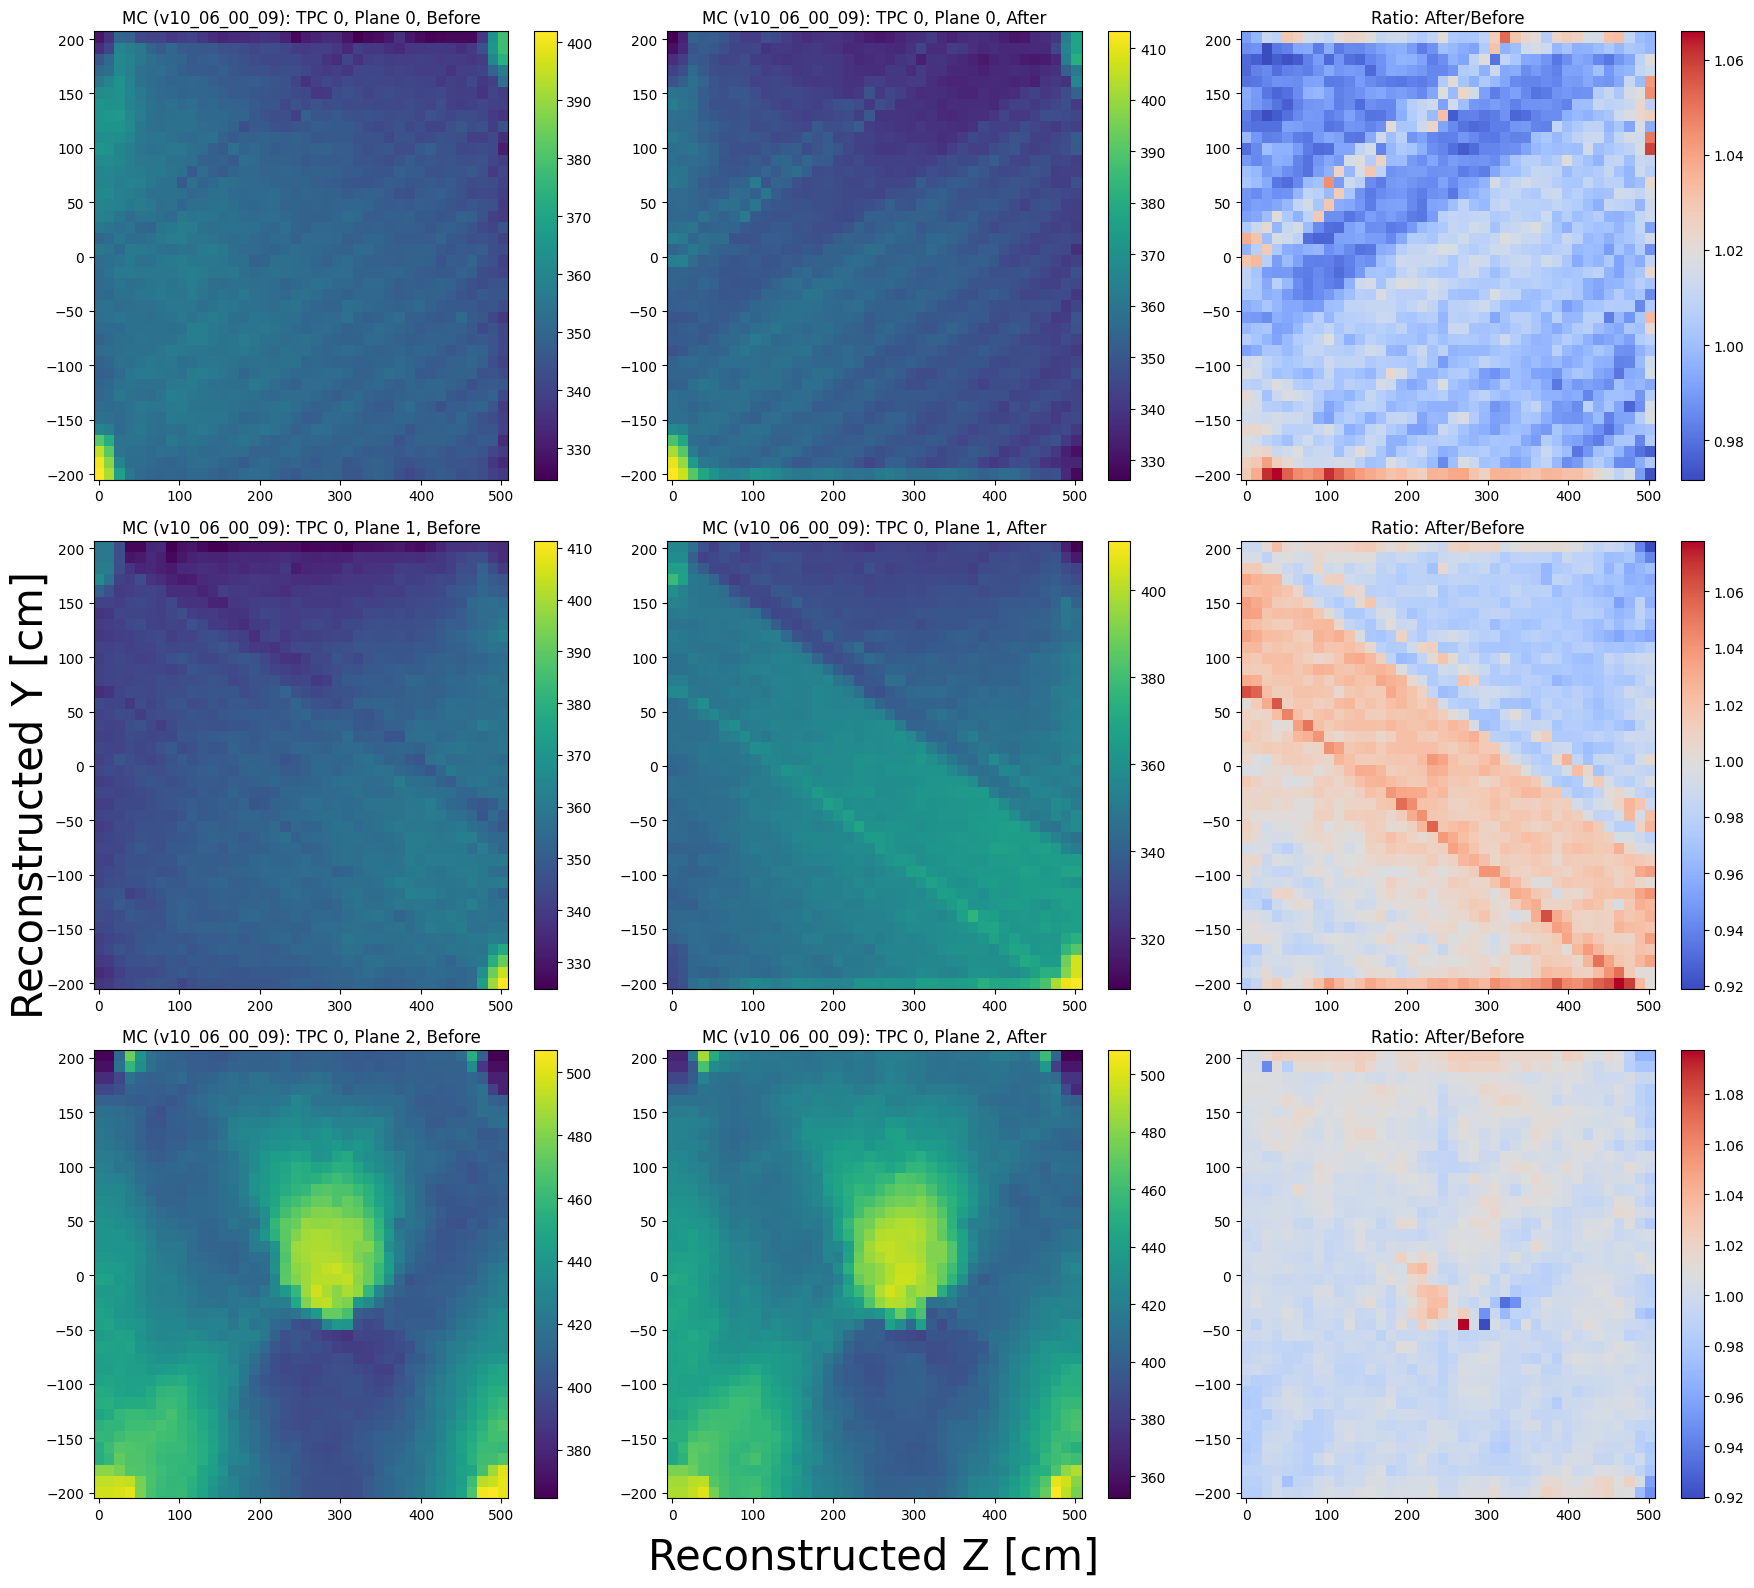

In [21]:
mc_mpv_names = [f"mc_mpv_{i}" for i in range(6)]
data_mpv_names = [f"data_mpv_{i}" for i in range(6)]
TPC = 0
isData = False
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for plane in range(3):
    idx = 3*TPC + plane

    xb, yb, zb = 0, 0, 0
    xa, ya, za = 0, 0, 0
    if isData:
        xb, yb, zb = get_spline(fs, data_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, data_mpv_names[idx], transpose=True)
    else:
        xb, yb, zb = get_spline(fs, mc_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, mc_mpv_names[idx], transpose=True)
 
    ratio = za/zb

    pcm = axes[plane][0].pcolormesh(xb, yb, zb, cmap="viridis", rasterized=True, shading='auto')

    fig.colorbar(pcm, ax=axes[plane][0]) 
    if isData:
        axes[plane][0].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, Before")
        axes[plane][1].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, After") 
    else:
        axes[plane][0].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, Before")
        axes[plane][1].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, After")

    pcm = axes[plane][1].pcolormesh(xa, ya, za, cmap="viridis", rasterized=True, shading='auto')
    fig.colorbar(pcm, ax=axes[plane][1]) 

    pcm = axes[plane][2].pcolormesh(xa, ya, ratio, cmap="coolwarm", rasterized=True, shading='auto')
    fig.colorbar(pcm, ax=axes[plane][2]) 
    axes[plane][2].set_title(f"Ratio: After/Before")


fig.supxlabel("Reconstructed Z [cm]", fontsize=30)
fig.supylabel('Reconstructed Y [cm]', fontsize=30)
plt.tight_layout()
#plt.savefig(Figure_Dir + f"tracks_yz_east_tpc{TPC}_plane{plane}.png", bbox_inches="tight")
plt.show()


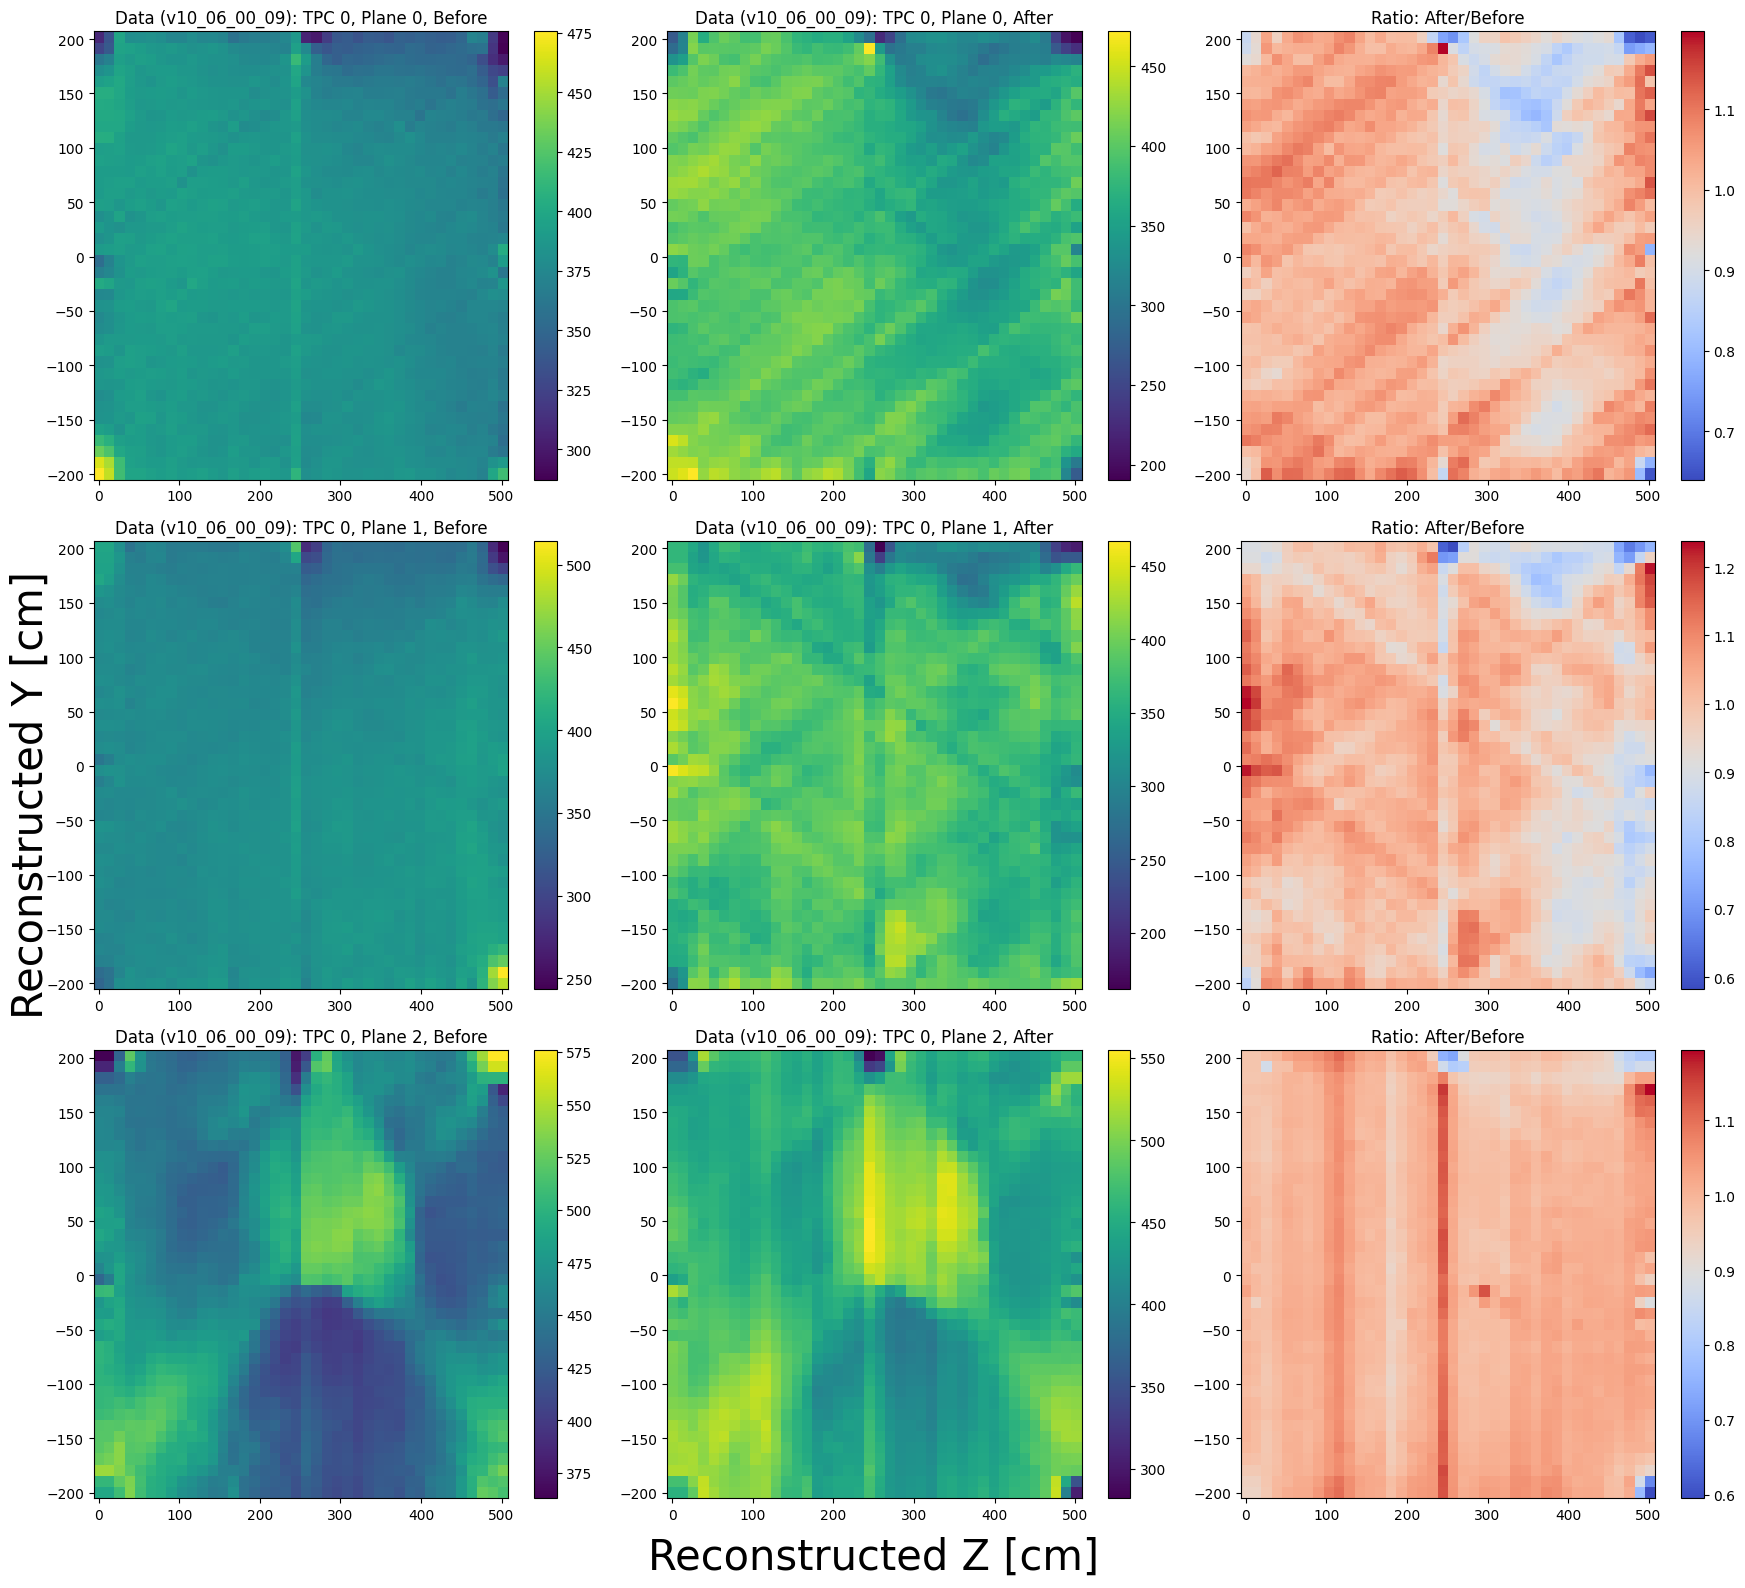

In [22]:
mc_mpv_names = [f"mc_mpv_{i}" for i in range(6)]
data_mpv_names = [f"data_mpv_{i}" for i in range(6)]
TPC = 0
isData = True
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for plane in range(3):
    idx = 3*TPC + plane

    xb, yb, zb = 0, 0, 0
    xa, ya, za = 0, 0, 0
    if isData:
        xb, yb, zb = get_spline(fs, data_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, data_mpv_names[idx], transpose=True)
    else:
        xb, yb, zb = get_spline(fs, mc_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, mc_mpv_names[idx], transpose=True)
 
    ratio = za/zb

    pcm = axes[plane][0].pcolormesh(xb, yb, zb, cmap="viridis", rasterized=True, shading='auto')

    fig.colorbar(pcm, ax=axes[plane][0]) 
    if isData:
        axes[plane][0].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, Before")
        axes[plane][1].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, After") 
    else:
        axes[plane][0].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, Before")
        axes[plane][1].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, After")

    pcm = axes[plane][1].pcolormesh(xa, ya, za, cmap="viridis", rasterized=True, shading='auto')
    fig.colorbar(pcm, ax=axes[plane][1]) 

    pcm = axes[plane][2].pcolormesh(xa, ya, ratio, cmap="coolwarm", rasterized=True, shading='auto')
    fig.colorbar(pcm, ax=axes[plane][2]) 
    axes[plane][2].set_title(f"Ratio: After/Before")


fig.supxlabel("Reconstructed Z [cm]", fontsize=30)
fig.supylabel('Reconstructed Y [cm]', fontsize=30)
plt.tight_layout()
#plt.savefig(Figure_Dir + f"tracks_yz_east_tpc{TPC}_plane{plane}.png", bbox_inches="tight")
plt.show()


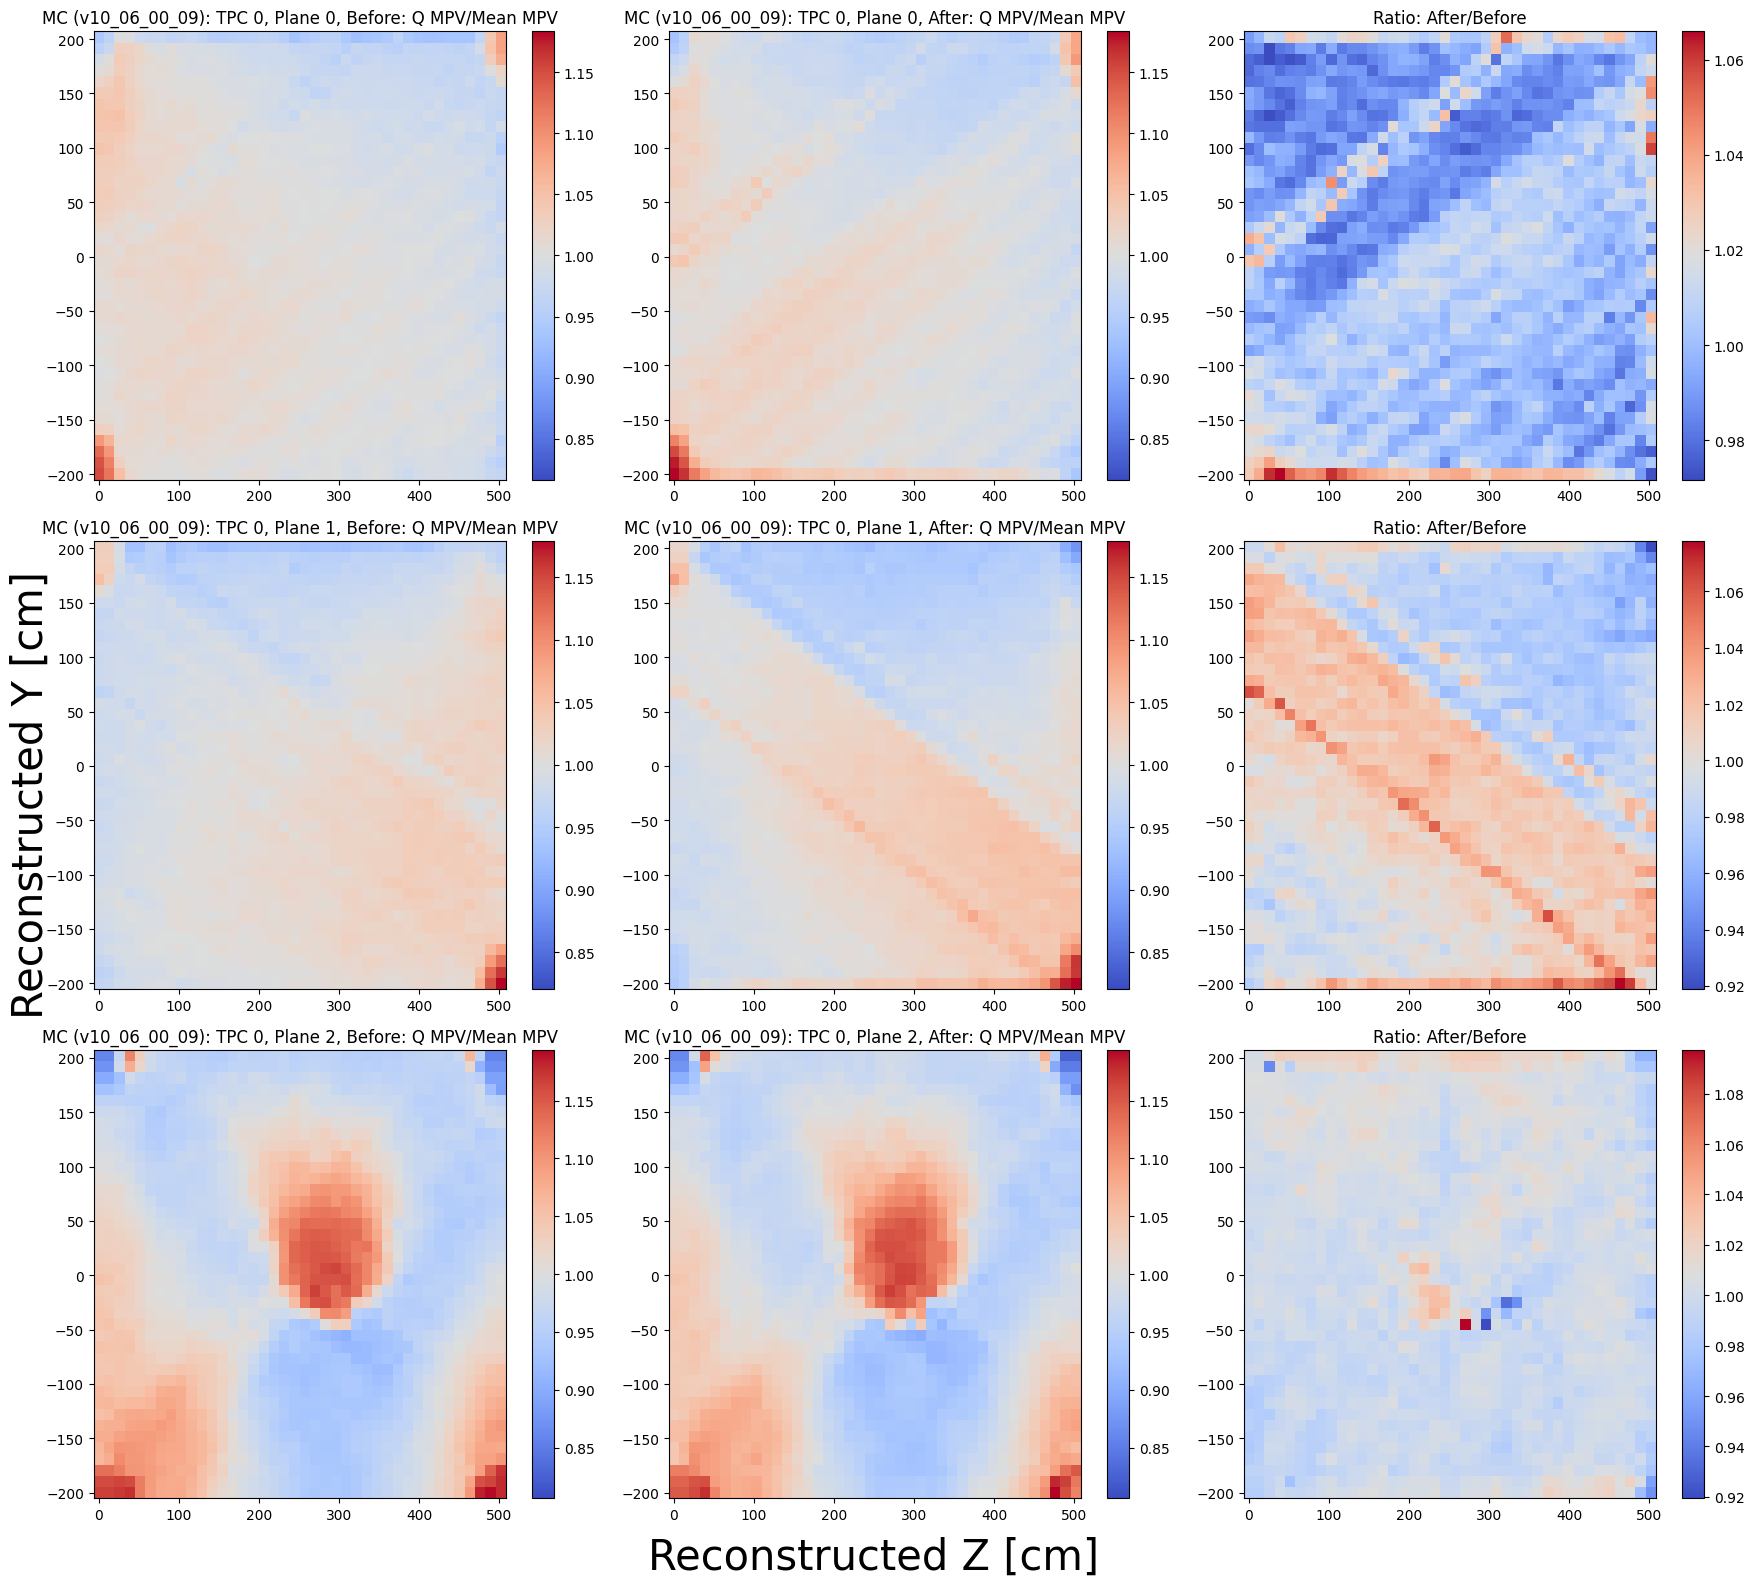

In [31]:
mc_mpv_names = [f"mc_mpv_{i}" for i in range(6)]
data_mpv_names = [f"data_mpv_{i}" for i in range(6)]
TPC = 0
isData = False
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for plane in range(3):
    idx = 3*TPC + plane

    xb, yb, zb = 0, 0, 0
    xa, ya, za = 0, 0, 0
    if isData:
        xb, yb, zb = get_spline(fs, data_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, data_mpv_names[idx], transpose=True)
    else:
        xb, yb, zb = get_spline(fs, mc_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, mc_mpv_names[idx], transpose=True)
 
    ratio = za/zb

    minv = min([np.min(za/np.mean(za)), np.min(zb/np.mean(zb))])
    maxv = max([np.max(za/np.mean(za)), np.max(zb/np.mean(zb))])

    dev = 0
    dev_min = abs(1-minv)
    dev_max = abs(1-maxv)
    if dev_max > dev_min:
        dev = dev_max
    else:
        dev = dev_min

    #dev = 0.15

    pcm = axes[plane][0].pcolormesh(xb, yb, zb/np.mean(zb), cmap="coolwarm", rasterized=True, shading='auto', vmin=1-dev, vmax=1+dev)

    fig.colorbar(pcm, ax=axes[plane][0]) 
    if isData:
        axes[plane][0].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, Before: Q MPV/Mean MPV")
        axes[plane][1].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, After: Q MPV/Mean MPV") 
    else:
        axes[plane][0].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, Before: Q MPV/Mean MPV")
        axes[plane][1].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, After: Q MPV/Mean MPV")

    pcm = axes[plane][1].pcolormesh(xa, ya, za/np.mean(za), cmap="coolwarm", rasterized=True, shading='auto', vmin=1-dev, vmax=1+dev)
    fig.colorbar(pcm, ax=axes[plane][1]) 

    pcm = axes[plane][2].pcolormesh(xa, ya, ratio, cmap="coolwarm", rasterized=True, shading='auto')
    fig.colorbar(pcm, ax=axes[plane][2]) 
    axes[plane][2].set_title(f"Ratio: After/Before")


fig.supxlabel("Reconstructed Z [cm]", fontsize=30)
fig.supylabel('Reconstructed Y [cm]', fontsize=30)
plt.tight_layout()
#plt.savefig(Figure_Dir + f"tracks_yz_east_tpc{TPC}_plane{plane}.png", bbox_inches="tight")
plt.show()


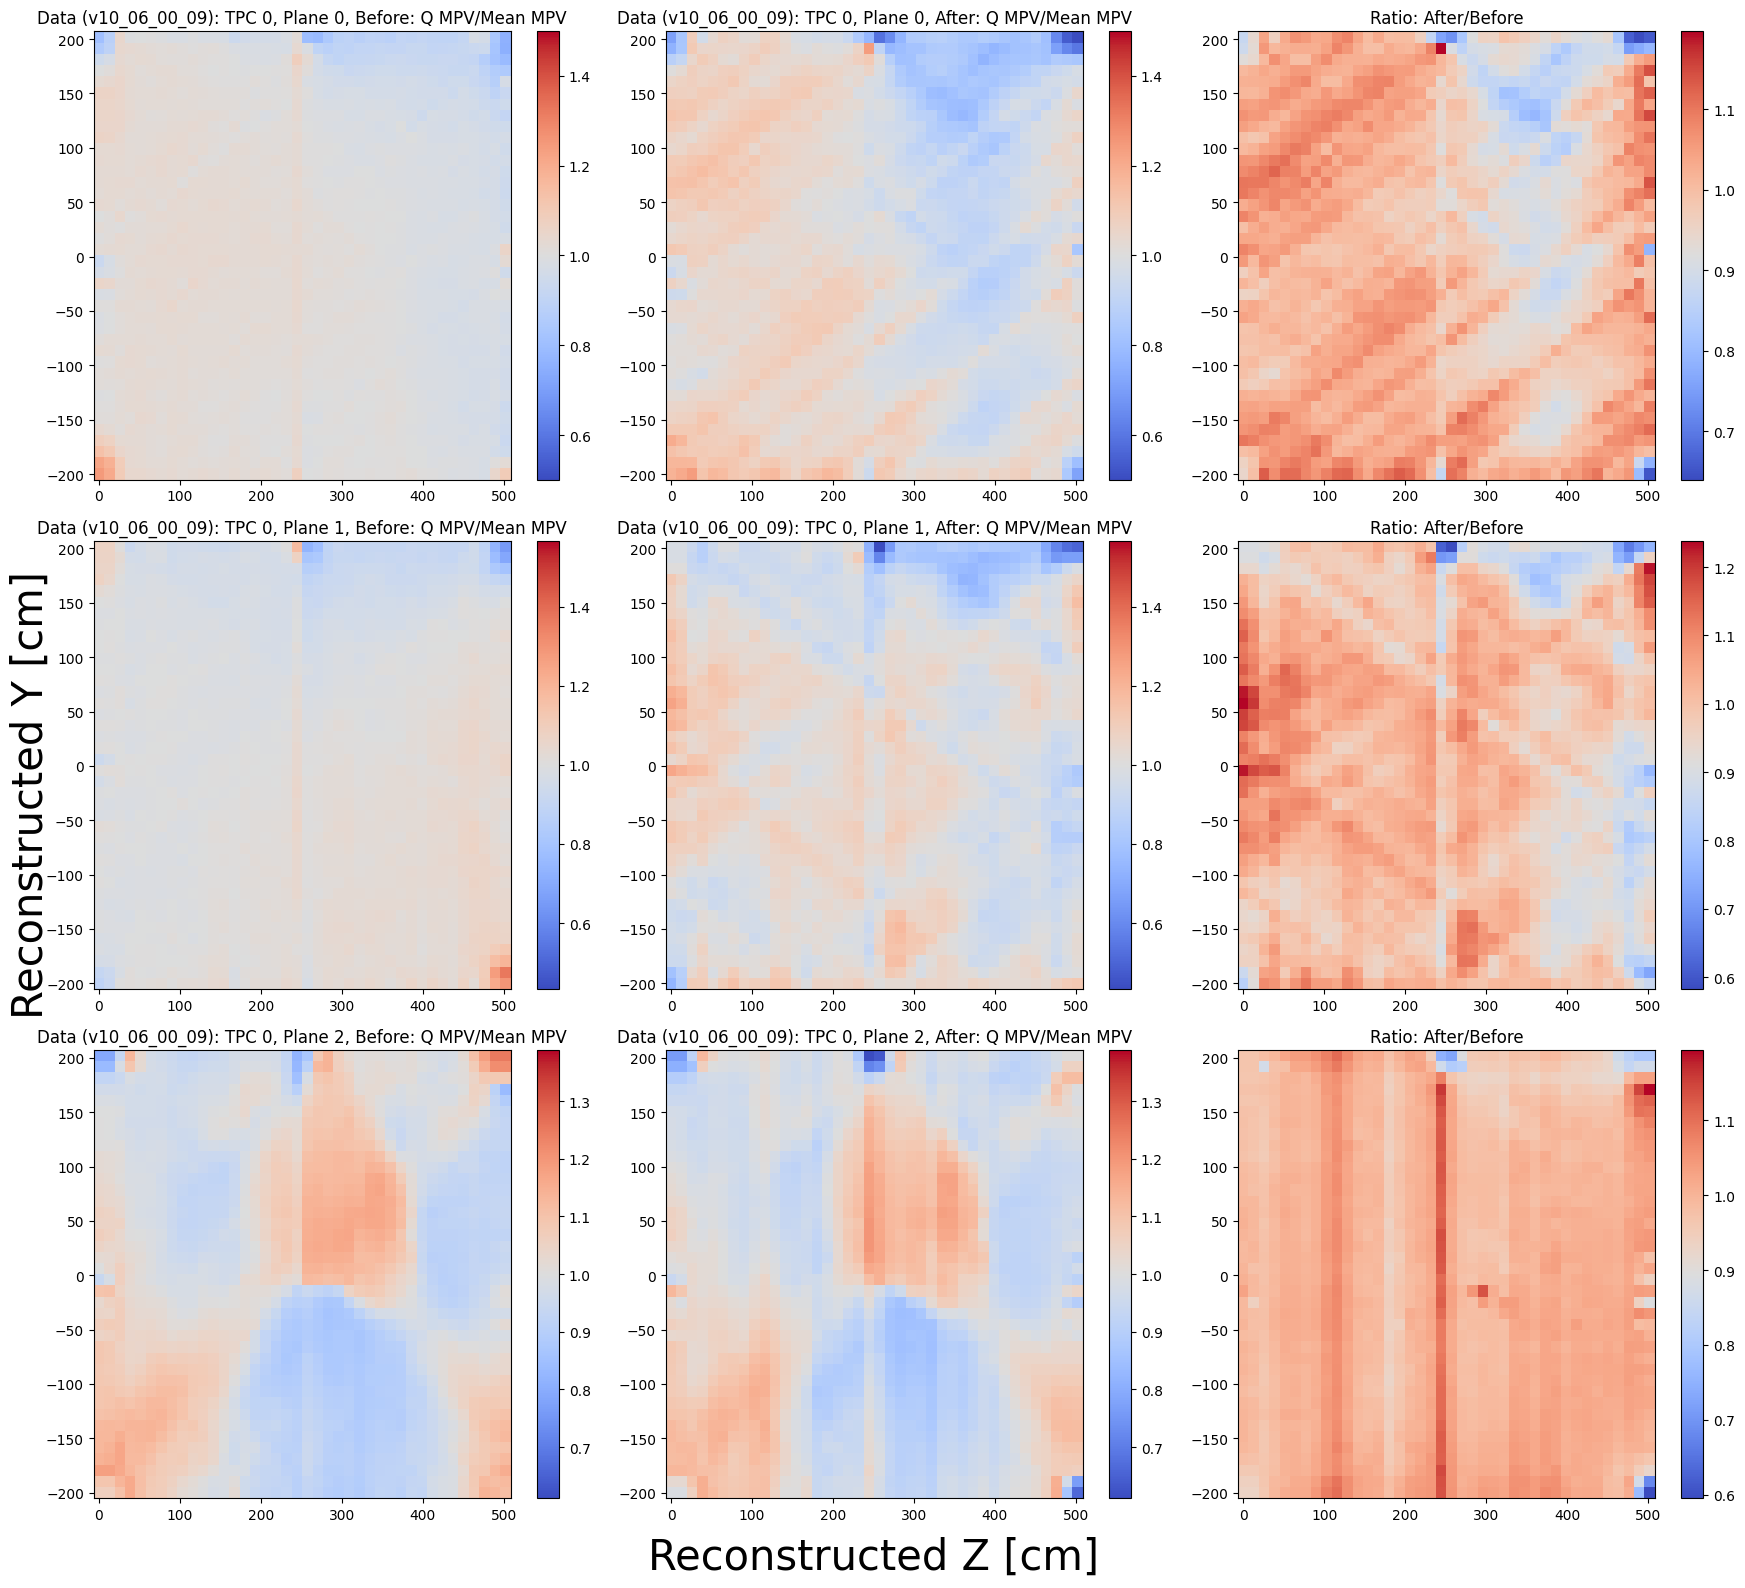

In [32]:
mc_mpv_names = [f"mc_mpv_{i}" for i in range(6)]
data_mpv_names = [f"data_mpv_{i}" for i in range(6)]
TPC = 0
isData = True
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for plane in range(3):
    idx = 3*TPC + plane

    xb, yb, zb = 0, 0, 0
    xa, ya, za = 0, 0, 0
    if isData:
        xb, yb, zb = get_spline(fs, data_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, data_mpv_names[idx], transpose=True)
    else:
        xb, yb, zb = get_spline(fs, mc_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, mc_mpv_names[idx], transpose=True)
 
    ratio = za/zb

    minv = min([np.min(za/np.mean(za)), np.min(zb/np.mean(zb))])
    maxv = max([np.max(za/np.mean(za)), np.max(zb/np.mean(zb))])

    dev = 0
    dev_min = abs(1-minv)
    dev_max = abs(1-maxv)
    if dev_max > dev_min:
        dev = dev_max
    else:
        dev = dev_min

    #dev = 0.15

    pcm = axes[plane][0].pcolormesh(xb, yb, zb/np.mean(zb), cmap="coolwarm", rasterized=True, shading='auto', vmin=1-dev, vmax=1+dev)

    fig.colorbar(pcm, ax=axes[plane][0]) 
    if isData:
        axes[plane][0].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, Before: Q MPV/Mean MPV")
        axes[plane][1].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, After: Q MPV/Mean MPV") 
    else:
        axes[plane][0].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, Before: Q MPV/Mean MPV")
        axes[plane][1].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, After: Q MPV/Mean MPV")

    pcm = axes[plane][1].pcolormesh(xa, ya, za/np.mean(za), cmap="coolwarm", rasterized=True, shading='auto', vmin=1-dev, vmax=1+dev)
    fig.colorbar(pcm, ax=axes[plane][1]) 

    pcm = axes[plane][2].pcolormesh(xa, ya, ratio, cmap="coolwarm", rasterized=True, shading='auto')
    fig.colorbar(pcm, ax=axes[plane][2]) 
    axes[plane][2].set_title(f"Ratio: After/Before")


fig.supxlabel("Reconstructed Z [cm]", fontsize=30)
fig.supylabel('Reconstructed Y [cm]', fontsize=30)
plt.tight_layout()
#plt.savefig(Figure_Dir + f"tracks_yz_east_tpc{TPC}_plane{plane}.png", bbox_inches="tight")
plt.show()


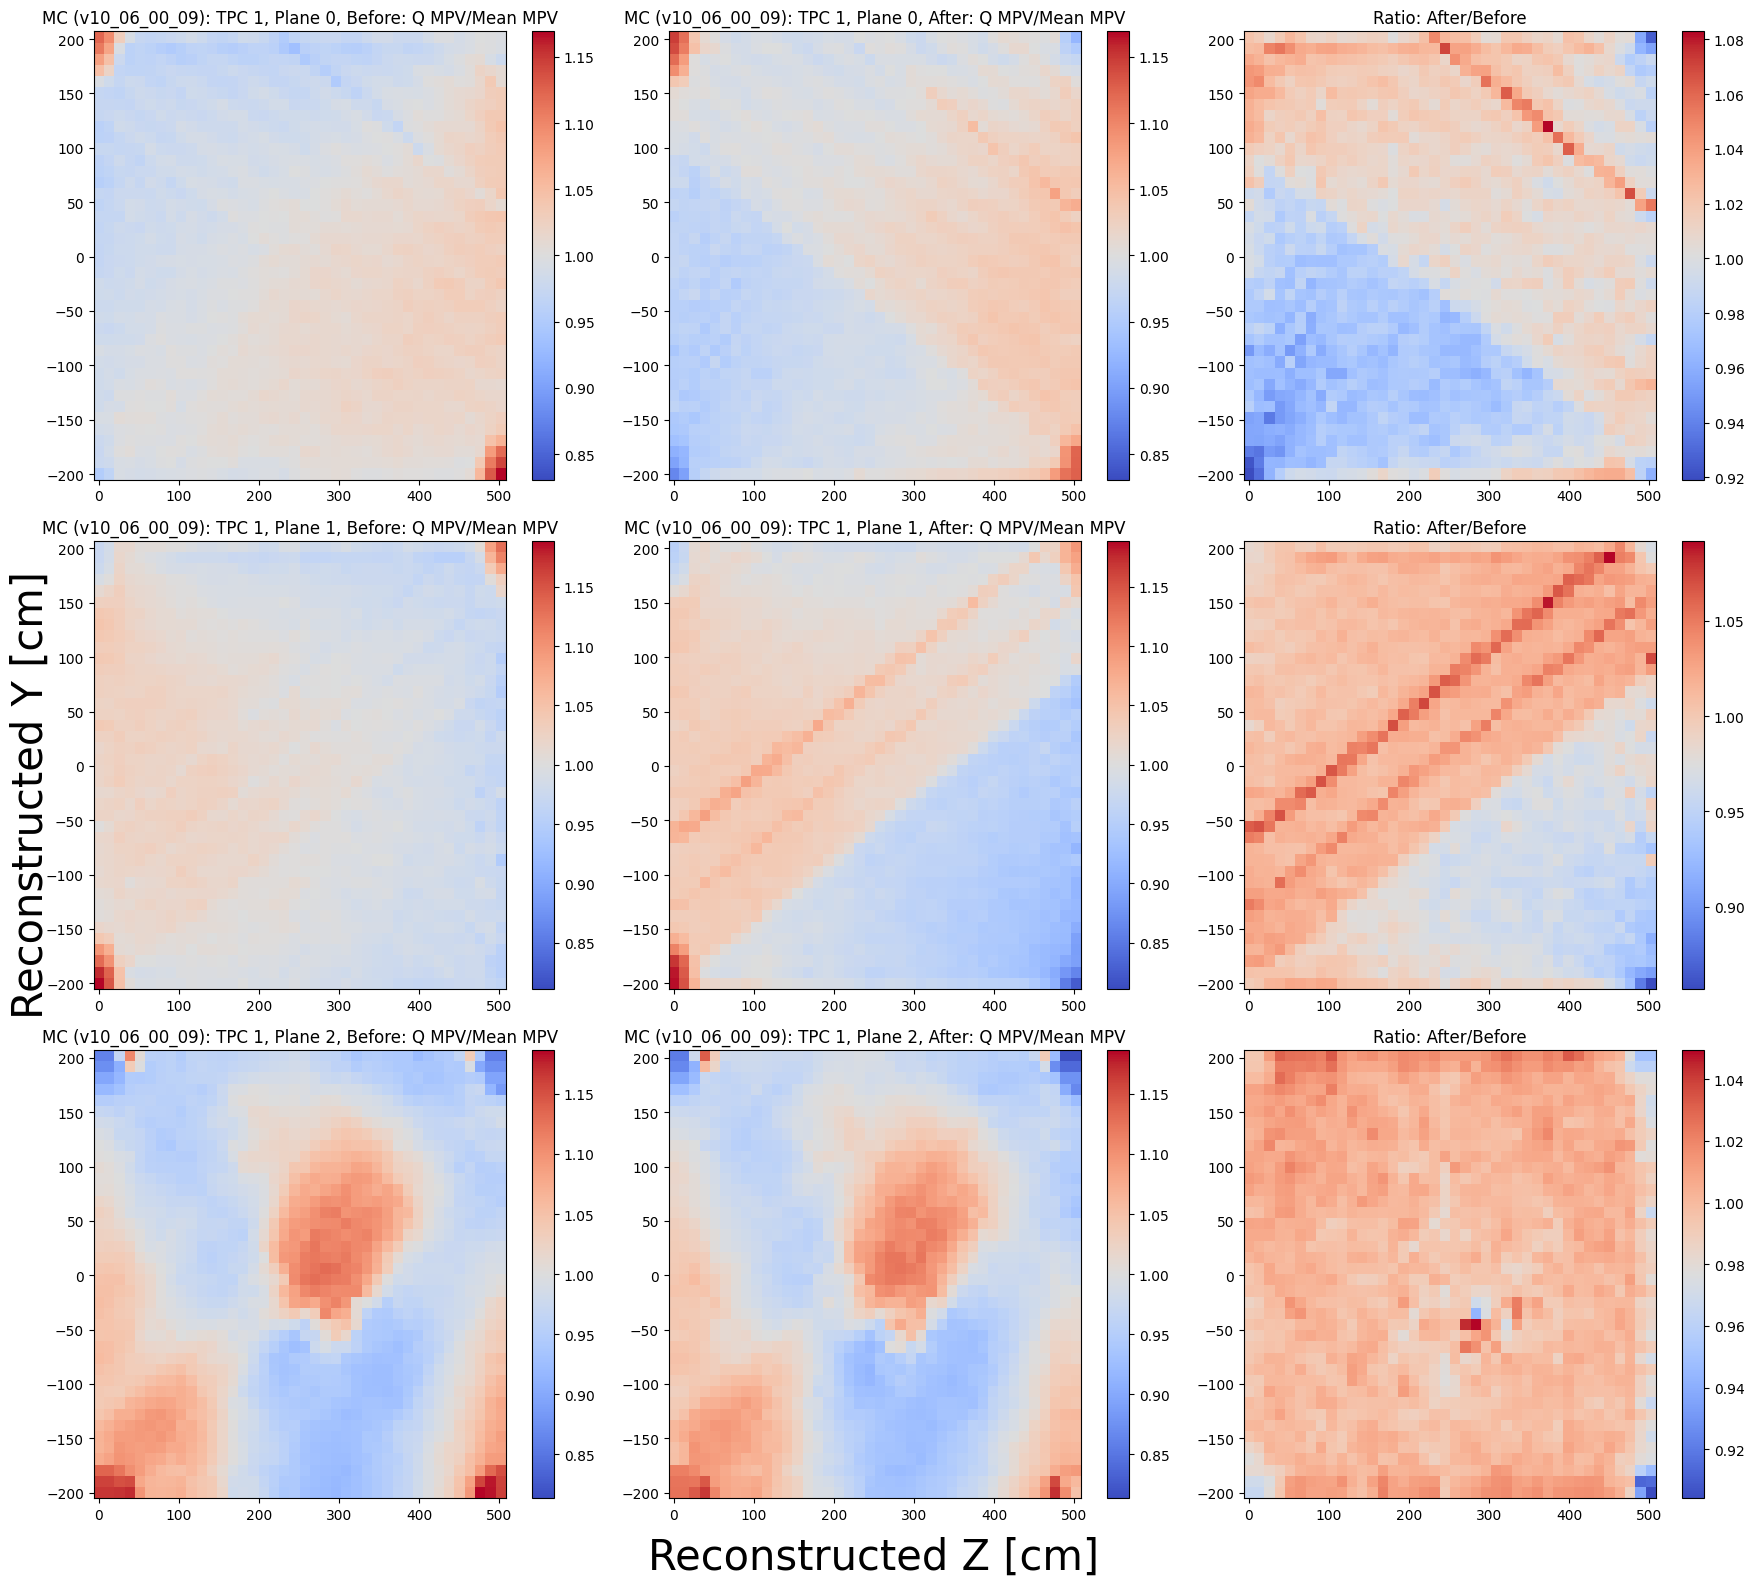

In [33]:
mc_mpv_names = [f"mc_mpv_{i}" for i in range(6)]
data_mpv_names = [f"data_mpv_{i}" for i in range(6)]
TPC = 1
isData = False
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for plane in range(3):
    idx = 3*TPC + plane

    xb, yb, zb = 0, 0, 0
    xa, ya, za = 0, 0, 0
    if isData:
        xb, yb, zb = get_spline(fs, data_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, data_mpv_names[idx], transpose=True)
    else:
        xb, yb, zb = get_spline(fs, mc_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, mc_mpv_names[idx], transpose=True)
 
    ratio = za/zb

    minv = min([np.min(za/np.mean(za)), np.min(zb/np.mean(zb))])
    maxv = max([np.max(za/np.mean(za)), np.max(zb/np.mean(zb))])

    dev = 0
    dev_min = abs(1-minv)
    dev_max = abs(1-maxv)
    if dev_max > dev_min:
        dev = dev_max
    else:
        dev = dev_min

    #dev = 0.15

    pcm = axes[plane][0].pcolormesh(xb, yb, zb/np.mean(zb), cmap="coolwarm", rasterized=True, shading='auto', vmin=1-dev, vmax=1+dev)

    fig.colorbar(pcm, ax=axes[plane][0]) 
    if isData:
        axes[plane][0].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, Before: Q MPV/Mean MPV")
        axes[plane][1].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, After: Q MPV/Mean MPV") 
    else:
        axes[plane][0].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, Before: Q MPV/Mean MPV")
        axes[plane][1].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, After: Q MPV/Mean MPV")

    pcm = axes[plane][1].pcolormesh(xa, ya, za/np.mean(za), cmap="coolwarm", rasterized=True, shading='auto', vmin=1-dev, vmax=1+dev)
    fig.colorbar(pcm, ax=axes[plane][1]) 

    pcm = axes[plane][2].pcolormesh(xa, ya, ratio, cmap="coolwarm", rasterized=True, shading='auto')
    fig.colorbar(pcm, ax=axes[plane][2]) 
    axes[plane][2].set_title(f"Ratio: After/Before")


fig.supxlabel("Reconstructed Z [cm]", fontsize=30)
fig.supylabel('Reconstructed Y [cm]', fontsize=30)
plt.tight_layout()
#plt.savefig(Figure_Dir + f"tracks_yz_east_tpc{TPC}_plane{plane}.png", bbox_inches="tight")
plt.show()


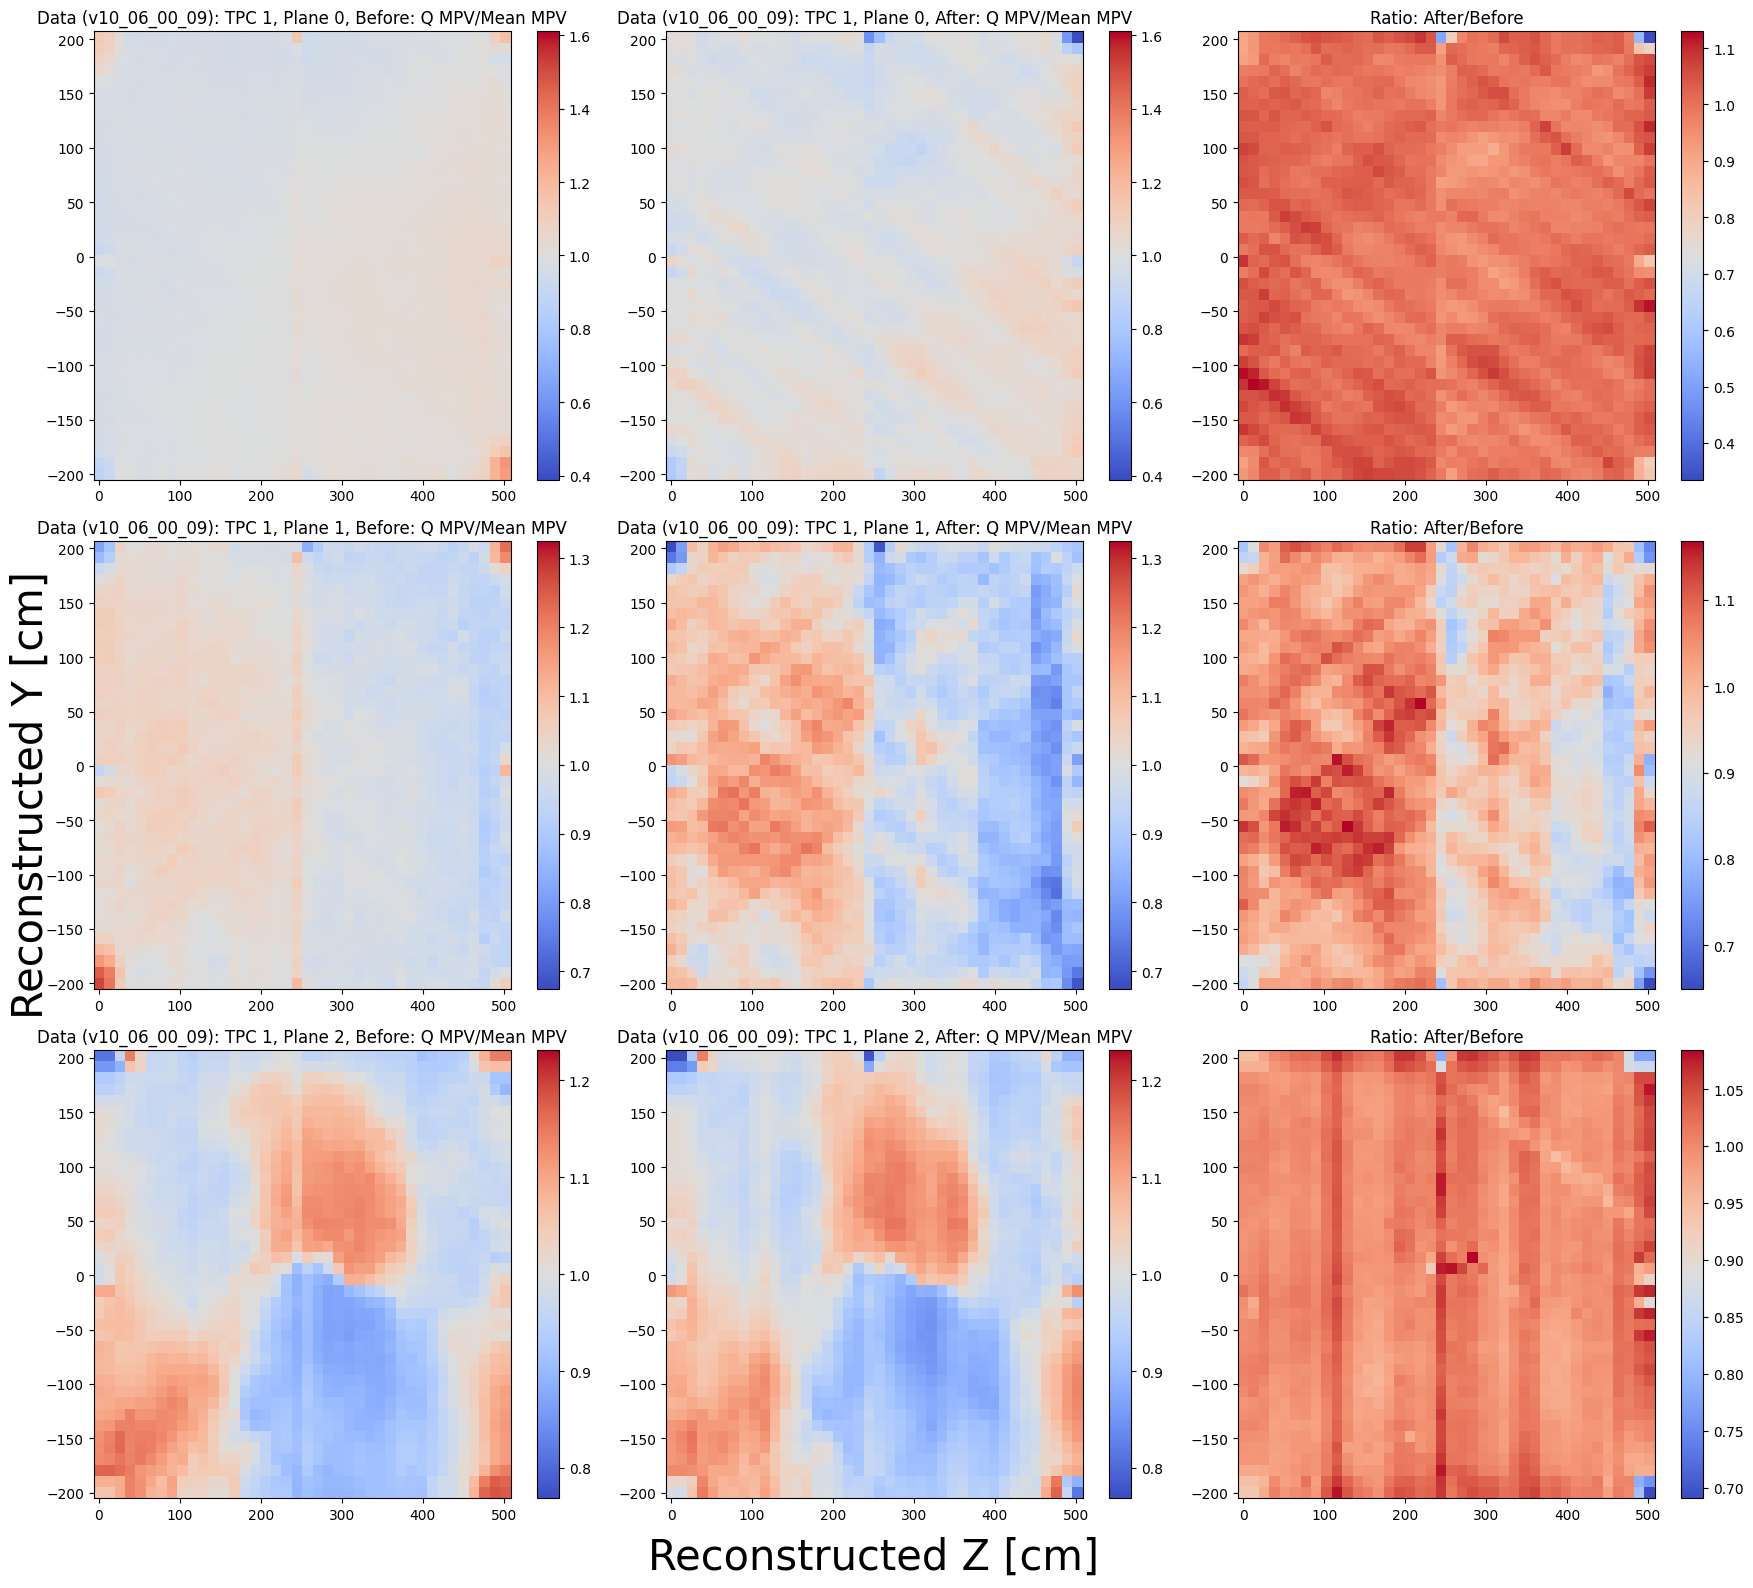

In [34]:
mc_mpv_names = [f"mc_mpv_{i}" for i in range(6)]
data_mpv_names = [f"data_mpv_{i}" for i in range(6)]
TPC = 1
isData = True
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for plane in range(3):
    idx = 3*TPC + plane

    xb, yb, zb = 0, 0, 0
    xa, ya, za = 0, 0, 0
    if isData:
        xb, yb, zb = get_spline(fs, data_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, data_mpv_names[idx], transpose=True)
    else:
        xb, yb, zb = get_spline(fs, mc_mpv_names[idx], transpose=True)
        xa, ya, za = get_spline(fs_corr, mc_mpv_names[idx], transpose=True)
 
    ratio = za/zb

    minv = min([np.min(za/np.mean(za)), np.min(zb/np.mean(zb))])
    maxv = max([np.max(za/np.mean(za)), np.max(zb/np.mean(zb))])

    dev = 0
    dev_min = abs(1-minv)
    dev_max = abs(1-maxv)
    if dev_max > dev_min:
        dev = dev_max
    else:
        dev = dev_min

    #dev = 0.15

    pcm = axes[plane][0].pcolormesh(xb, yb, zb/np.mean(zb), cmap="coolwarm", rasterized=True, shading='auto', vmin=1-dev, vmax=1+dev)

    fig.colorbar(pcm, ax=axes[plane][0]) 
    if isData:
        axes[plane][0].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, Before: Q MPV/Mean MPV")
        axes[plane][1].set_title(f"Data (v10_06_00_09): TPC {TPC}, Plane {plane}, After: Q MPV/Mean MPV") 
    else:
        axes[plane][0].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, Before: Q MPV/Mean MPV")
        axes[plane][1].set_title(f"MC (v10_06_00_09): TPC {TPC}, Plane {plane}, After: Q MPV/Mean MPV")

    pcm = axes[plane][1].pcolormesh(xa, ya, za/np.mean(za), cmap="coolwarm", rasterized=True, shading='auto', vmin=1-dev, vmax=1+dev)
    fig.colorbar(pcm, ax=axes[plane][1]) 

    pcm = axes[plane][2].pcolormesh(xa, ya, ratio, cmap="coolwarm", rasterized=True, shading='auto')
    fig.colorbar(pcm, ax=axes[plane][2]) 
    axes[plane][2].set_title(f"Ratio: After/Before")


fig.supxlabel("Reconstructed Z [cm]", fontsize=30)
fig.supylabel('Reconstructed Y [cm]', fontsize=30)
plt.tight_layout()
#plt.savefig(Figure_Dir + f"tracks_yz_east_tpc{TPC}_plane{plane}.png", bbox_inches="tight")
plt.show()


In [20]:
dadadawd

NameError: name 'dadadawd' is not defined

In [ ]:
def plot_mpv_comparison(fig, axes, isData, tpc, plane):
    mc_mpv_names = [f"mc_mpv_{i}" for i in range(6)]
    data_mpv_names = [f"data_mpv_{i}" for i in range(6)]
    idx = 3*tpc + plane
    xb, yb, zb = 0, 0, 0
    xa, ya, za = 0, 0, 0
    if isData:
        xb, yb, zb = get_spline(rs_file, data_mpv_names[idx])
        xa, ya, za = get_spline(rscorr_file, data_mpv_names[idx])
    else:
        xb, yb, zb = get_spline(rs_file, mc_mpv_names[idx])
        xa, ya, za = get_spline(rscorr_file, mc_mpv_names[idx])
    
    pcmb = axes[0][0].pcolormesh(xb, yb, zb, cmap='viridis', rasterized=True)
    pcma = axes[0][1].pcolormesh(xa, ya, za, cmap='viridis', rasterized=True)

    fig.colorbar(pcmb, ax=axes[0][0], label="Nominal MPV")
    fig.colorbar(pcma, ax=axes[0][1], label="Inverted MPV")

    

In [ ]:
def plot_mpv_check(root_file_before, root_file_after, zlabel="Data/MC"):

    tgraph_names = [f"splines_{i}" for i in range(6)]
    tgraph_titles = ['TPC 0 plane 0', 'TPC 0 plane 1', 'TPC 0 plane 2',
                 'TPC 1 plane 0', 'TPC 1 plane 1', 'TPC 1 plane 2']

    mc_mpv_names = [f"mc_mpv_{i}" for i in range(6)]
    #data_mpv_names = [f"data_mpv_{i}" for i in range(6)]

    for ig, gname in enumerate(tgraph_names):
        fig, ax = plt.subplots(2, 2, figsize=(10, 6))


        xib, yib, zib = get_spline(root_file_before, gname)
        #xia, yia, zia = get_spline(root_file_after, gname)
        
        xib_mpv, yib_mpv, zib_mpv = get_spline(root_file_before, mc_mpv_names[ig])
        xia_mpv, yia_mpv, zia_mpv = get_spline(root_file_after, mc_mpv_names[ig])      

        xia = xib
        yia = yib
        zia = zib*zib_mpv


        zmin=np.min(zib)
        zmax=np.max(zib)
        difflow = abs(1 - zmin)
        diffhigh = abs(zmax - 1)

        if difflow > diffhigh:
            zmax = 1 + difflow
        else:
            zmin = 1 - diffhigh

        # Set the spline colorbars
        pcmb = ax[0][0].pcolormesh(xib, yib, zib, cmap='coolwarm', rasterized=True, vmin=zmin, vmax=zmax)
        #pcma = ax[0][1].pcolormesh(xia, yia, zia, cmap='coolwarm', rasterized=True, vmin=zmin, vmax=zmax)

        zmin_mpv=np.min([np.min(zib_mpv), np.min(zia_mpv), np.min(zia)])
        zmax_mpv=np.max([np.max(zib_mpv), np.max(zia_mpv), np.max(zia)])

        # Set the MC MPV colorbars
        pcmb_mpv = ax[1][0].pcolormesh(xib_mpv, yib_mpv, zib_mpv, cmap='coolwarm', rasterized=True, vmin=zmin_mpv, vmax=zmax_mpv)
        pcma_mpv = ax[1][1].pcolormesh(xia_mpv, yia_mpv, zia_mpv, cmap='coolwarm', rasterized=True, vmin=zmin_mpv, vmax=zmax_mpv)
        pcma = ax[0][1].pcolormesh(xia, yia, zia, cmap='coolwarm', rasterized=True, vmin=zmin_mpv, vmax=zmax_mpv)

        #ax[0][0].set_xlabel("x (cm)")
        #ax[0][0].set_ylabel(r"$\theta_{xw}$ (cm)")
        #ax[0][1].set_xlabel("x (cm)")
        #ax[0][1].set_ylabel(r"$\theta_{xw}$ (cm)")

        ax[0][0].set_title(tgraph_titles[ig]+ " (Before)")
        ax[0][1].set_title(tgraph_titles[ig]+ " (After)")

        ax[0][0].tick_params(axis='both', direction='in', top=True, right=True)
        ax[0][1].tick_params(axis='both', direction='in', top=True, right=True)
        ax[1][0].tick_params(axis='both', direction='in', top=True, right=True)
        ax[1][1].tick_params(axis='both', direction='in', top=True, right=True)

        fig.colorbar(pcmb, ax=ax[0][0], label=zlabel)
        fig.colorbar(pcma, ax=ax[0][1], label="MC MPV Before * Spline")

        fig.colorbar(pcmb_mpv, ax=ax[1][0], label="MC MPV")
        fig.colorbar(pcma_mpv, ax=ax[1][1], label="MC MPV")

        fig.supxlabel("x (cm)", fontsize=20)
        fig.supylabel(r"$\theta_{xw}$ (cm)", fontsize=20)
      
        plt.tight_layout()

        # Save with high DPI
        #plt.savefig(f"plot_{gname}.pdf", dpi=300)
        plt.show()
